# 3. Model Experimentation, Tuning & Evaluation

This notebook handles training Baseline (A4) and Attention (A5) models, performing Hyperparameter Tuning with Keras Tuner, and finally visualizing their performance side-by-side.

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import keras_tuner as kt
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## 1. Load Random-Split Dataset

In [3]:
X_train = np.load('../data/processed/features_random/train/X.npy')
y_train = np.load('../data/processed/features_random/train/y.npy')
X_val = np.load('../data/processed/features_random/val/X.npy')
y_val = np.load('../data/processed/features_random/val/y.npy')
X_test = np.load('../data/processed/features_random/test/X.npy')
y_test = np.load('../data/processed/features_random/test/y.npy')

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Val shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(11520, 400, 40), y=(11520,)
Val shapes: X=(288, 400, 40), y=(288,)
Test shapes: X=(288, 400, 40), y=(288,)


## 2. Architecture Definitions

In [4]:
@keras.utils.register_keras_serializable()
class SoftAttention(layers.Layer):
    """
    Soft attention mechanism over BiLSTM outputs.

    For each time step t:
        score_t = tanh(W · h_t)          [learned weight vector W]
        alpha_t = softmax(score_t)        [normalised weights]
        context = Σ alpha_t * h_t         [weighted sum]

    This matches the formulation in Zennou et al. (2026), Eq. 5–6.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # W: (feature_dim,) — one weight per feature dimension
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1],),
            initializer="glorot_uniform",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, encoder_output):
        # encoder_output: (batch, T, features)
        score   = tf.nn.tanh(encoder_output * self.W)   # (batch, T, features)
        score   = tf.reduce_sum(score, axis=-1, keepdims=True)  # (batch, T, 1)
        weights = tf.nn.softmax(score, axis=1)           # (batch, T, 1)
        context = tf.reduce_sum(weights * encoder_output, axis=1)  # (batch, features)
        return context, weights

    def get_config(self):
        return super().get_config()


def prelu_block(x, filters: int, kernel_size: int, dropout: float,
                name_prefix: str, l2: float = 1e-4):
    """Conv1D → PReLU → MaxPool(2) → Dropout (paper Table I)."""
    x = layers.Conv1D(
        filters, kernel_size, padding="same",
        kernel_regularizer=regularizers.l2(l2),
        name=f"{name_prefix}_conv"
    )(x)
    x = layers.PReLU(name=f"{name_prefix}_prelu")(x)
    x = layers.MaxPooling1D(2, name=f"{name_prefix}_pool")(x)
    x = layers.Dropout(dropout, name=f"{name_prefix}_drop")(x)
    return x


def build_baseline_model(
    input_shape: tuple,
    n_classes: int,
    conv1_filters: int   = 64,   conv1_kernel: int = 3,
    conv2_filters: int   = 128,  conv2_kernel: int = 5,
    conv3_filters: int   = 256,  conv3_kernel: int = 7,
    lstm_units:    int   = 64,
    dense1_units:  int   = 128,
    dense2_units:  int   = 64,
    dropout_conv:  float = 0.3,
    dropout_dense: float = 0.3,
    l2_reg:        float = 1e-4,
    learning_rate: float = 0.001,
) -> keras.Model:
    """
    Configuration A4 from ETASR paper:
      CNN (3 blocks) → 90.21% on RAVDESS.
    """
    inp = keras.Input(shape=input_shape, name="input_features")

    # CNN blocks
    x = prelu_block(inp, conv1_filters, conv1_kernel, dropout_conv, "conv1", l2=l2_reg)
    x = prelu_block(x,   conv2_filters, conv2_kernel, dropout_conv, "conv2", l2=l2_reg)
    x = prelu_block(x,   conv3_filters, conv3_kernel, dropout_conv, "conv3", l2=l2_reg)

    x = layers.GlobalAveragePooling1D(name="pool")(x)

    # Dense head
    x   = layers.Dense(dense1_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense1")(x)
    x   = layers.PReLU(name="dense1_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense1")(x)
    x   = layers.Dense(dense2_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense2")(x)
    x   = layers.PReLU(name="dense2_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense2")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="CNN_BiLSTM_A4")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_bilstm_model(
    input_shape: tuple,
    n_classes: int,
    conv1_filters: int   = 64,   conv1_kernel: int = 3,
    conv2_filters: int   = 128,  conv2_kernel: int = 5,
    conv3_filters: int   = 256,  conv3_kernel: int = 7,
    lstm_units:    int   = 64,
    dense1_units:  int   = 128,
    dense2_units:  int   = 64,
    dropout_conv:  float = 0.3,
    dropout_dense: float = 0.3,
    l2_reg:        float = 1e-4,
    learning_rate: float = 0.001,
) -> keras.Model:
    """
    Configuration A4 from ETASR paper:
      CNN (3 blocks) + BiLSTM (no attention) → 90.21% on RAVDESS.
    """
    inp = keras.Input(shape=input_shape, name="input_features")

    # CNN blocks
    x = prelu_block(inp, conv1_filters, conv1_kernel, dropout_conv, "conv1", l2=l2_reg)
    x = prelu_block(x,   conv2_filters, conv2_kernel, dropout_conv, "conv2", l2=l2_reg)
    x = prelu_block(x,   conv3_filters, conv3_kernel, dropout_conv, "conv3", l2=l2_reg)

    # BiLSTM — returns final hidden state only (no attention)
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False,
                    kernel_regularizer=regularizers.l2(l2_reg)), name="bilstm"
    )(x)

    # Dense head
    x   = layers.Dense(dense1_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense1")(x)
    x   = layers.PReLU(name="dense1_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense1")(x)
    x   = layers.Dense(dense2_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense2")(x)
    x   = layers.PReLU(name="dense2_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense2")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="CNN_BiLSTM_A4")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_attention_model(
    input_shape: tuple,
    n_classes: int,
    conv1_filters: int   = 64,   conv1_kernel: int = 3,
    conv2_filters: int   = 128,  conv2_kernel: int = 5,
    conv3_filters: int   = 256,  conv3_kernel: int = 7,
    lstm_units:    int   = 64,
    dense1_units:  int   = 128,
    dense2_units:  int   = 64,
    dropout_conv:  float = 0.3,
    dropout_dense: float = 0.3,
    l2_reg:        float = 1e-4,
    learning_rate: float = 0.001,
) -> keras.Model:
    """
    Configuration A5 — proposed model from ETASR paper:
      CNN (3 blocks) + BiLSTM + Soft Attention → 91.74% on RAVDESS.
    """
    inp = keras.Input(shape=input_shape, name="input_features")

    # CNN blocks (3 × PReLU + MaxPool + Dropout)
    x = prelu_block(inp, conv1_filters, conv1_kernel, dropout_conv, "conv1", l2=l2_reg)
    x = prelu_block(x,   conv2_filters, conv2_kernel, dropout_conv, "conv2", l2=l2_reg)
    x = prelu_block(x,   conv3_filters, conv3_kernel, dropout_conv, "conv3", l2=l2_reg)

    # BiLSTM — returns sequences for attention
    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                    kernel_regularizer=regularizers.l2(l2_reg)), name="bilstm"
    )(x)

    # Soft attention
    context, _ = SoftAttention(name="attention")(x)

    # Dense head
    x   = layers.Dense(dense1_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense1")(context)
    x   = layers.PReLU(name="dense1_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense1")(x)
    x   = layers.Dense(dense2_units, kernel_regularizer=regularizers.l2(l2_reg), name="dense2")(x)
    x   = layers.PReLU(name="dense2_prelu")(x)
    x   = layers.Dropout(dropout_dense, name="drop_dense2")(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="CNN_BiLSTM_Attention_A5")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


## 3. Train Baseline | Bi-LSTM | Attention Models

In [5]:
input_shape = (400, 40)
n_classes = len(np.unique(y_train))

baseline_model = build_baseline_model(input_shape, n_classes)
baseline_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
history_base = baseline_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[baseline_cb])
baseline_model.save('../models/baseline_random_best.keras')
with open('../models/baseline_random_history.json', 'w') as f: json.dump(history_base.history, f)

2026-06-01 14:56:21.581615: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-01 14:56:21.581710: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-01 14:56:21.581725: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-06-01 14:56:21.581776: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-01 14:56:21.581797: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2026-06-01 14:56:22.755961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


360/360 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.2812 - loss: 1.8253 - val_accuracy: 0.3681 - val_loss: 1.6397
Epoch 2/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4499 - loss: 1.4201 - val_accuracy: 0.5556 - val_loss: 1.1849
Epoch 3/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5793 - loss: 1.1531 - val_accuracy: 0.6944 - val_loss: 0.9023
Epoch 4/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6652 - loss: 0.9664 - val_accuracy: 0.7743 - val_loss: 0.7116
Epoch 5/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7390 - loss: 0.7920 - val_accuracy: 0.8299 - val_loss: 0.6148
Epoch 6/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7851 - loss: 0.6867 - val_accuracy: 0.8333 - val_loss: 0.5233
Epoch 7/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8225 - loss: 0.5915 - val_accuracy: 0.7778 - val_loss: 0.6669
Epoch 8/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8549 - loss: 0.5165 - val_accuracy: 0.871

In [ ]:
bilstm_model = build_bilstm_model(input_shape, n_classes)
bilstm_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
history_bilstm = bilstm_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[bilstm_cb])
bilstm_model.save('../models/bilstm_random_best.keras')
with open('../models/bilstm_random_history.json', 'w') as f: json.dump(history_bilstm.history, f)

attention_model = build_attention_model(input_shape, n_classes)
attention_cb = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
history_attn = attention_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[attention_cb])
attention_model.save('../models/attention_random_best.keras')
with open('../models/attention_random_history.json', 'w') as f: json.dump(history_attn.history, f)

print("Training code is ready. Uncomment to execute.")

Epoch 1/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.2984 - loss: 1.8533 - val_accuracy: 0.3854 - val_loss: 1.6669
Epoch 2/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4798 - loss: 1.4436 - val_accuracy: 0.6007 - val_loss: 1.1273
Epoch 3/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6010 - loss: 1.1890 - val_accuracy: 0.7326 - val_loss: 0.8763
Epoch 4/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6743 - loss: 1.0188 - val_accuracy: 0.7986 - val_loss: 0.7130
Epoch 5/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7504 - loss: 0.8839 - val_accuracy: 0.8542 - val_loss: 0.6463
Epoch 6/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7990 - loss: 0.7860 - val_accuracy: 0.9028 - val_loss: 0.6113
Epoch 7/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8251 - loss: 0.7432 - val_accuracy: 0.8819 - val_loss: 0.6243
Epoch 8/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8526 - loss: 0.6948 - val_acc

## 4. Hyperparameter Tuning (Attention Model)

In [ ]:
def build_tunable_model(hp):
    inputs = keras.Input(shape=input_shape)
    
    hp_filters = hp.Int('filters', min_value=64, max_value=256, step=64)
    hp_lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    hp_lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    # CNN blocks using prelu_block
    x = prelu_block(inputs, filters=hp_filters, kernel_size=5, dropout=hp_dropout, name_prefix="t_conv1")
    x = prelu_block(x, filters=hp_filters, kernel_size=5, dropout=hp_dropout, name_prefix="t_conv2")
    x = prelu_block(x, filters=hp_filters * 2, kernel_size=5, dropout=hp_dropout, name_prefix="t_conv3")

    # BiLSTM
    x = layers.Bidirectional(layers.LSTM(hp_lstm_units, return_sequences=True))(x)
    
    # Attention
    context, _ = SoftAttention(name='t_attention')(x)

    # Dense Head
    x = layers.Dense(128)(context)
    x = layers.PReLU()(x)
    x = layers.Dropout(hp_dropout)(x)
    
    x = layers.Dense(64)(x)
    x = layers.PReLU()(x)
    x = layers.Dropout(hp_dropout)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tune r = kt.Hyperband(
    build_tunable_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='../models/tuner_logs',
    project_name='ser_attention_tuning_random'
)


early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
tuner.search(X_train, y_train, epochs=20, validation_data=(X_val, y_val), callbacks=[early_stop])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)
callbacks = [keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)]
history_tuned = best_model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=callbacks)

best_model.save('../models/attention_tuned_random_best.keras')
with open('../models/attention_tuned_random_history.json', 'w') as f: json.dump(history_tuned.history, f)

print("Tuner setup complete. Uncomment to execute search and final training.")


Trial 30 Complete [00h 10m 43s]
val_accuracy: 0.9270833134651184

Best val_accuracy So Far: 0.9791666865348816
Total elapsed time: 03h 37m 22s
Epoch 1/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.2836 - loss: 1.8261 - val_accuracy: 0.3681 - val_loss: 1.6245
Epoch 2/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.4802 - loss: 1.3985 - val_accuracy: 0.6076 - val_loss: 1.0493
Epoch 3/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.6781 - loss: 0.9339 - val_accuracy: 0.7500 - val_loss: 0.7384
Epoch 4/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 36s 101ms/step - accuracy: 0.7965 - loss: 0.6302 - val_accuracy: 0.8333 - val_loss: 0.4938
Epoch 5/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.8652 - loss: 0.4557 - val_accuracy: 0.8993 - val_loss: 0.3530
Epoch 6/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 36s 100ms/step - accuracy: 0.9086 - loss: 0.3289 - val_accuracy: 0.9479 - val_loss: 0.2063
Epoch 7/50
360/360 ━━━━━━━━━━━━━━━━━━━━ 36s 100ms/step - accuracy: 0.924

## 5. Evaluation & Comparison

Reads all `*random_history.json` and `*random_best.keras` files to plot their learning curves and compare test set accuracies side-by-side.

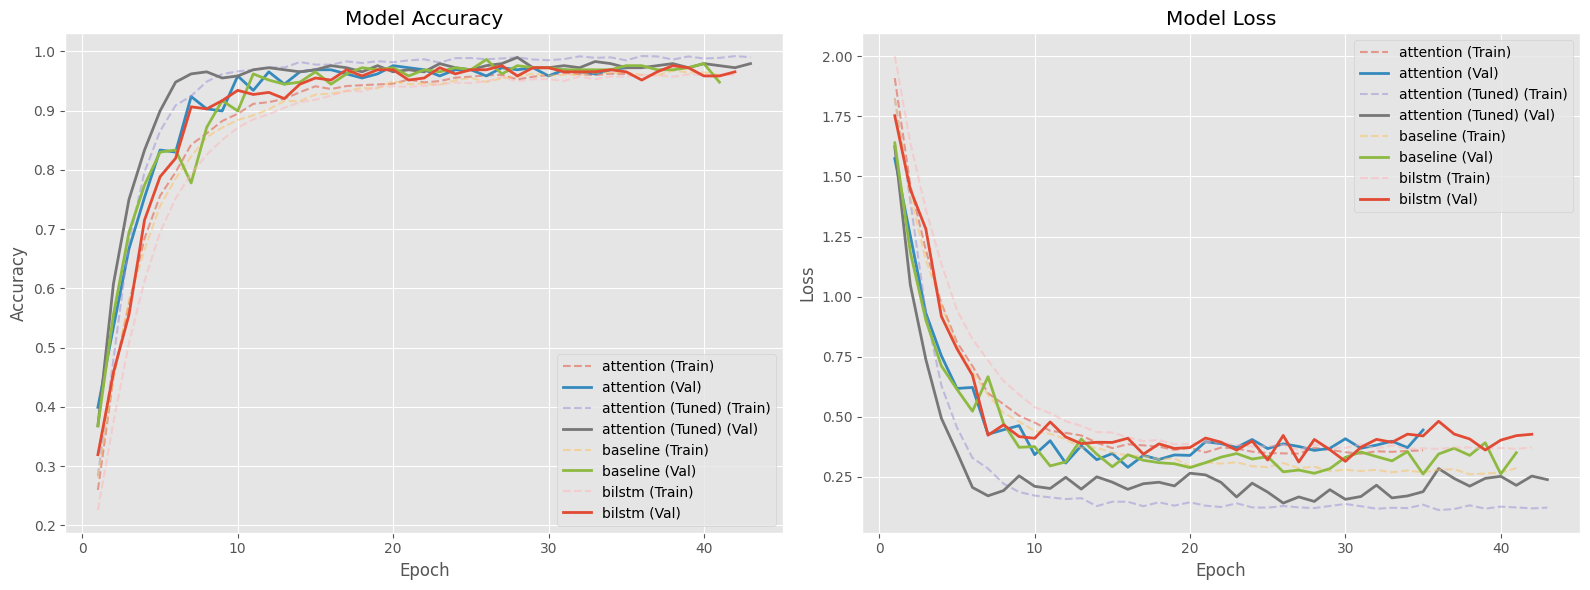

In [6]:
history_files = sorted(glob.glob('../models/*random_history*.json'))
histories = {}

for f in history_files:
    model_name = os.path.basename(f).split('_')[0]
    if 'tuned' in f:
        model_name += ' (Tuned)'
    with open(f, 'r') as fp: histories[model_name] = json.load(fp)

if histories:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for name, hist in histories.items():
        epochs = range(1, len(hist['accuracy']) + 1)
        axes[0].plot(epochs, hist['accuracy'], linestyle='--', alpha=0.5, label=f'{name} (Train)')
        axes[0].plot(epochs, hist['val_accuracy'], linewidth=2, label=f'{name} (Val)')
        axes[1].plot(epochs, hist['loss'], linestyle='--', alpha=0.5, label=f'{name} (Train)')
        axes[1].plot(epochs, hist['val_loss'], linewidth=2, label=f'{name} (Val)')

    axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
    axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("No history JSON files found. Run the training cells above first.")

Evaluating models on Test Set...


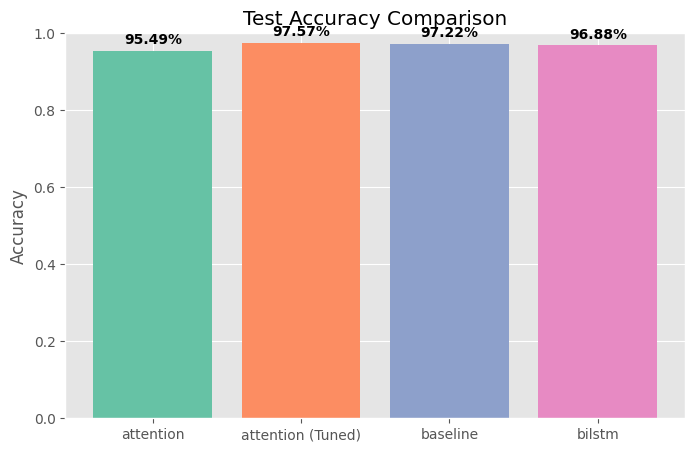

In [7]:
model_files = sorted(glob.glob('../models/*random_best.keras'))
test_results = {}

if model_files:
    print("Evaluating models on Test Set...")
    for m_file in model_files:
        model_name = os.path.basename(m_file).split('_')[0]
        if 'tuned' in m_file:
            model_name += ' (Tuned)'
            
        model = tf.keras.models.load_model(m_file, custom_objects={'SoftAttention': SoftAttention}, compile=False)
        model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        test_results[model_name] = acc

    plt.figure(figsize=(8, 5))
    names = list(test_results.keys())
    accuracies = list(test_results.values())

    bars = plt.bar(names, accuracies, color=sns.color_palette("Set2"))
    plt.title("Test Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.0)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

    plt.show()
else:
    print("No .keras files found. Run the training cells above first.")